# Setup

In [1]:
from IPython.display import HTML, IFrame, clear_output, display
import random
import torch
from rich import print as rprint
from rich.table import Table
from tqdm.auto import tqdm
from functools import partial
import torch as t
import torch.nn.functional as F
from torch import Tensor, nn
from jaxtyping import Float, Int
import einops

import matplotlib.pyplot as plt
import numpy as np

device = t.device("mps" if t.backends.mps.is_available() else "cuda" if t.cuda.is_available() else "cpu")

from sae_lens import (
    SAE,
    ActivationsStore,
    HookedSAETransformer,
    LanguageModelSAERunnerConfig,
    SAEConfig,
    SAETrainingRunner,
    upload_saes_to_huggingface,
)

from transformer_lens import ActivationCache, HookedTransformer, utils
from transformer_lens.hook_points import HookPoint
# from tabulate import tabulate

C:\Anaconda\envs\fyp\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# from huggingface_hub import login
# login()

In [3]:
# import inspect
# print(inspect.getfile(gemma_2_2b.__class__))

In [4]:
# gemma-2-2b has layer 0 to layer 25

gemmascope_sae_release = "gemma-scope-2b-pt-mlp-canonical"
# gemmascope_sae_id = "layer_20/width_16k/canonical"
gemmascope_all_sae_ids = [
    f"layer_{i}/width_16k/canonical" for i in range(0,26)
]

In [5]:
gemmascope_all_sae_ids

['layer_0/width_16k/canonical',
 'layer_1/width_16k/canonical',
 'layer_2/width_16k/canonical',
 'layer_3/width_16k/canonical',
 'layer_4/width_16k/canonical',
 'layer_5/width_16k/canonical',
 'layer_6/width_16k/canonical',
 'layer_7/width_16k/canonical',
 'layer_8/width_16k/canonical',
 'layer_9/width_16k/canonical',
 'layer_10/width_16k/canonical',
 'layer_11/width_16k/canonical',
 'layer_12/width_16k/canonical',
 'layer_13/width_16k/canonical',
 'layer_14/width_16k/canonical',
 'layer_15/width_16k/canonical',
 'layer_16/width_16k/canonical',
 'layer_17/width_16k/canonical',
 'layer_18/width_16k/canonical',
 'layer_19/width_16k/canonical',
 'layer_20/width_16k/canonical',
 'layer_21/width_16k/canonical',
 'layer_22/width_16k/canonical',
 'layer_23/width_16k/canonical',
 'layer_24/width_16k/canonical',
 'layer_25/width_16k/canonical']

In [6]:
gemma_2_2b = HookedSAETransformer.from_pretrained("gemma-2-2b", device=device)

`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|█████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 40.34it/s]


Loaded pretrained model gemma-2-2b into HookedTransformer


In [7]:
# gemma_2_2b_sae = SAE.from_pretrained(gemmascope_sae_release, gemmascope_sae_id, device=str(device))[0]
gemma_2_2b_all_sae = [
    SAE.from_pretrained(gemmascope_sae_release, i, device=str(device))[0] for i in gemmascope_all_sae_ids
]

C:\Users\Pey Ruo-Yang\AppData\Local\Temp\ipykernel_9508\3035216223.py:3: DeprecationWarning: Indexing SAE objects is deprecated. SAE.from_pretrained() now returns only the SAE object. Use SAE.from_pretrained_with_cfg_and_sparsity() to get the config dict and sparsity as well.
  SAE.from_pretrained(gemmascope_sae_release, i, device=str(device))[0] for i in gemmascope_all_sae_ids


In [8]:
gemma_2_2b_all_sae[0].threshold.max()

tensor(9.8752, device='cuda:0', grad_fn=<MaxBackward1>)

# Test

In [9]:
prompt = "The reliability of Wikipedia is very"
answer = "yo"
utils.test_prompt(prompt, answer, gemma_2_2b)

Tokenized prompt: ['<bos>', 'The', ' reliability', ' of', ' Wikipedia', ' is', ' very']
Tokenized answer: [' yo']


Performance on answer token:
Rank: 12147    Logit:  5.29 Prob:  0.00% Token: | yo|

Top 0th token. Logit: 25.89 Prob: 20.21% Token: | important|
Top 1th token. Logit: 25.41 Prob: 12.50% Token: | much|
Top 2th token. Logit: 25.30 Prob: 11.16% Token: | high|
Top 3th token. Logit: 25.27 Prob: 10.80% Token: | low|
Top 4th token. Logit: 25.14 Prob:  9.48% Token: | questionable|
Top 5th token. Logit: 24.59 Prob:  5.47% Token: | poor|
Top 6th token. Logit: 24.40 Prob:  4.55% Token: | good|
Top 7th token. Logit: 23.56 Prob:  1.96% Token: | well|
Top 8th token. Logit: 23.51 Prob:  1.87% Token: | controversial|
Top 9th token. Logit: 23.24 Prob:  1.42% Token: | often|


Ranks of the answer tokens: [(' yo', 12147)]

In [10]:
prompt_2= "The reliability of Wikipedia is very important"

In [11]:
GENERATE_KWARGS = dict(temperature=0.5, freq_penalty=2.0, verbose=False)
gemma_2_2b.generate(prompt_2, max_new_tokens=50, **GENERATE_KWARGS)

"The reliability of Wikipedia is very important. I think that the fact that a lot of people use it to gain knowledge and information makes this fact even more important. The problem is that not everyone can come up with an article in their own words, so they use other people's articles"

# SAE

In [12]:
logits, cache = gemma_2_2b.run_with_cache_with_saes(prompt, saes=gemma_2_2b_all_sae)

for name, param in cache.items():
    print(f"{name:<43}: {tuple(param.shape)}")

hook_embed                                 : (1, 7, 2304)
blocks.0.hook_resid_pre                    : (1, 7, 2304)
blocks.0.ln1.hook_scale                    : (1, 7, 1)
blocks.0.ln1.hook_normalized               : (1, 7, 2304)
blocks.0.attn.hook_q                       : (1, 7, 8, 256)
blocks.0.attn.hook_k                       : (1, 7, 4, 256)
blocks.0.attn.hook_v                       : (1, 7, 4, 256)
blocks.0.attn.hook_rot_q                   : (1, 7, 8, 256)
blocks.0.attn.hook_rot_k                   : (1, 7, 4, 256)
blocks.0.attn.hook_attn_scores             : (1, 8, 7, 7)
blocks.0.attn.hook_pattern                 : (1, 8, 7, 7)
blocks.0.attn.hook_z                       : (1, 7, 8, 256)
blocks.0.ln1_post.hook_scale               : (1, 7, 1)
blocks.0.ln1_post.hook_normalized          : (1, 7, 2304)
blocks.0.hook_attn_out                     : (1, 7, 2304)
blocks.0.hook_resid_mid                    : (1, 7, 2304)
blocks.0.ln2.hook_scale                    : (1, 7, 1)
blocks.0.ln

In [13]:
m=cache['blocks.20.hook_mlp_out.hook_sae_recons']
# m=cache['blocks.20.attn.hook_z.hook_sae_input']
m.shape

torch.Size([1, 7, 2304])

(-0.5, 47.5, 47.5, -0.5)

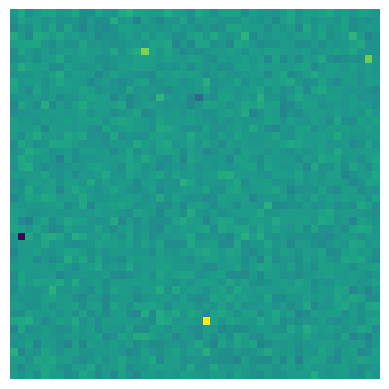

In [14]:
plt.imshow(m[0, -1, :].detach().cpu().numpy().reshape(48,48))
plt.axis('off')

In [15]:
m=cache['blocks.20.hook_mlp_out.hook_sae_acts_post'].detach().cpu().numpy()
print(m)

[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]]


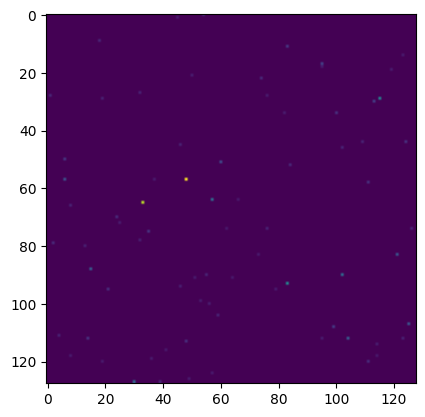

In [16]:
plt.imshow(m[0, -1, :].reshape(128,128))

In [17]:
top_indices = np.argsort(np.abs(m[0,-1]))[-10:][::-1]
m[0,-1][top_indices]

array([43.1297   , 38.718006 , 19.613232 , 18.810635 , 14.649522 ,
       14.325588 , 13.920195 , 12.1156025, 12.091032 , 10.924782 ],
      dtype=float32)

In [18]:
top_indices

array([ 7344,  8353, 11987,  3827,  8249, 11622, 16286, 11279, 14440,
       10745], dtype=int64)

# Getting features from all layers

In [19]:
def display_dashboard(
    layer=0,
    latent_idx=0,
    width=1200,
    height=800,
):

    url = f"https://neuronpedia.org/gemma-2-2b/{layer}-gemmascope-mlp-16k/{latent_idx}?embed=true&embedexplanation=true&embedplots=true&embedtest=true&height=300"

    print(url)
    display(IFrame(url, width=width, height=height))

In [20]:
features = []
residual_l = []
for i in range(0, 26):
    plt.figure()
    
    m=cache[f'blocks.{str(i)}.hook_mlp_out.hook_sae_acts_post'].detach().cpu().numpy()
    features.append(m)
    # plt.imshow(m[0, -1, :].reshape(128,128))
    # plt.title(f"Layer {str(i)} features")
    # plt.show()
    # plt.close()

    r=cache[f'blocks.{i}.hook_resid_post'].detach().cpu().numpy() # r shape is (1, seq len, 2304)
    # print(r.shape)
    # residual_l.append(r)
    # plt.imshow(r[0, -1, :].reshape(48,48))
    # plt.title(f"Layer {str(i)} residual stream")
    # plt.show()
    # plt.close()
    
    top_indices = np.argsort(np.abs(m[0,-1]))[-10:][::-1][:5]
    print(f"Layer {str(i)} top feature indices: {top_indices}")
    for ind in top_indices:
        # print(f"Latent {ind} had activation {act:.2f}")
        # display_dashboard(latent_idx=ind)
        display_dashboard(layer=i, latent_idx=ind)

Layer 0 top feature indices: [16248  7697 15083  3851 12681]
https://neuronpedia.org/gemma-2-2b/0-gemmascope-mlp-16k/16248?embed=true&embedexplanation=true&embedplots=true&embedtest=true&height=300


https://neuronpedia.org/gemma-2-2b/0-gemmascope-mlp-16k/7697?embed=true&embedexplanation=true&embedplots=true&embedtest=true&height=300


https://neuronpedia.org/gemma-2-2b/0-gemmascope-mlp-16k/15083?embed=true&embedexplanation=true&embedplots=true&embedtest=true&height=300


https://neuronpedia.org/gemma-2-2b/0-gemmascope-mlp-16k/3851?embed=true&embedexplanation=true&embedplots=true&embedtest=true&height=300


https://neuronpedia.org/gemma-2-2b/0-gemmascope-mlp-16k/12681?embed=true&embedexplanation=true&embedplots=true&embedtest=true&height=300


...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [21]:
r=cache['blocks.25.hook_resid_post']
l = gemma_2_2b.unembed(r)
probs=l[:,-1,:].softmax(dim=-1)
token_probs, token_ids = probs[-1, :].topk(10, dim=-1)

for tk, p in zip(token_ids, token_probs):
    print(gemma_2_2b.to_string(tk.item()))

 good
 important
 high
 much
 questionable
 different
 low
 well
 difficult
,


# Idea: zero out certain features and see how it affects the downstream features and final output

In [22]:
activations_from_steering_hook = {}

def steering_hook(
    activations: Float[Tensor, "batch pos d_in"],
    hook: HookPoint,
    sae: SAE,
    latent_idx: int,
    layer_idx: int,
    steering_coefficient: float,
) -> Tensor:
    """
    Steers the model by returning a modified activations tensor, with some multiple of the steering vector added to all
    sequence positions.
    """
    activations_from_steering_hook[layer_idx] = activations[:, :-1, :]
    return activations + steering_coefficient * sae.W_dec[latent_idx] #Hmm wow how can we visualize this - interesting. Pretty simple in a way.


def generate_with_steering( #Ah I could do a version of this for neurons - right!
    model: HookedSAETransformer,
    sae: SAE,
    prompt: str,
    latent_idx: int,
    steering_coefficient: float = 1.0,
    max_new_tokens: int = 50,
):
    """
    Generates text with steering. A multiple of the steering vector (the decoder weight for this latent) is added to
    the last sequence position before every forward pass.
    """
    _steering_hook = partial(
        steering_hook,
        sae=sae,
        latent_idx=latent_idx,
        steering_coefficient=steering_coefficient,
    )

    with model.hooks(fwd_hooks=[(sae.cfg.hook_name, _steering_hook)]):
        output = model.generate(prompt, max_new_tokens=max_new_tokens, **GENERATE_KWARGS)

    return output

In [23]:
gemma_2_2b.reset_hooks()
# latent_idx=12568
latent_idx=5365
# sae_layer=14
sae_layer=6
_steering_hook = partial(
    steering_hook,
    sae=gemma_2_2b_all_sae[sae_layer],
    latent_idx=latent_idx,
    layer_idx=sae_layer,
    steering_coefficient=100,
)
sae_layer_2=15
_steering_hook_2 = partial( # Make another hook with no steering coeff so it hooks the sae activations
    steering_hook,
    sae=gemma_2_2b_all_sae[sae_layer],
    latent_idx=latent_idx,
    layer_idx=sae_layer_2,
    steering_coefficient=0,
)
sae_layer_3=25
_steering_hook_3 = partial( # Make another hook with no steering coeff so it hooks the sae activations
    steering_hook,
    sae=gemma_2_2b_all_sae[sae_layer],
    latent_idx=latent_idx,
    layer_idx=sae_layer_3,
    steering_coefficient=0,
)
sae_layer_4=13
_steering_hook_4 = partial( # Make another hook with no steering coeff so it hooks the sae activations
    steering_hook,
    sae=gemma_2_2b_all_sae[sae_layer],
    latent_idx=latent_idx,
    layer_idx=sae_layer_4,
    steering_coefficient=0,
)

sae_input_hooks = {}

def capture_sae_input(x, hook):
    sae_input_hooks['activation'] = x.detach().clone()
    return x  # forward must return the input

# attach to the SAE's hook_sae_input
gemma_2_2b_all_sae[sae_layer].hook_sae_input.add_perma_hook(capture_sae_input)

# features_after_steering = []
residual_after_steering = {}

def capture_residual_hook(layer_idx):
    def hook_fn(
        activation: Float[Tensor, "batch pos d_model"],
        hook: HookPoint,
    ) -> None:
        """Capture residual stream for specific layer."""
        residual_after_steering[layer_idx] = activation.clone()
    return hook_fn
# Add hooks to capture residuals
residual_hooks_after_steering = []
for layer in range(26):
    residual_hooks_after_steering.append((f"blocks.{layer}.hook_resid_post", capture_residual_hook(layer)))

mlp_out_after_steering = {}

def capture_mlp_out_hook(layer_idx):
    def hook_fn(
        activation: Float[Tensor, "batch pos d_model"],
        hook: HookPoint,
    ) -> None:
        """Capture residual stream for specific layer."""
        mlp_out_after_steering[layer_idx] = activation.clone()
    return hook_fn
# Add hooks to capture residuals
mlp_out_hooks_after_steering = []
for layer in range(26):
    mlp_out_hooks_after_steering.append((f"blocks.{layer}.hook_mlp_out", capture_mlp_out_hook(layer)))

# with gemma_2_2b.hooks(fwd_hooks=[("blocks.20.hook_mlp_out", _steering_hook), *residual_hooks_after_steering]):
#     _, cache = gemma_2_2b.run_with_cache_with_saes(
#         prompt,
#         saes=gemma_2_2b_all_sae,
#         stop_at_layer=25+1,
#     )

In [24]:
# captured = {}

# def extract_sae(layer):
#     def hook_fn(activation, hook):
#         print(f"extracting sae input from layer {layer}")
#         captured[layer] = activation.detach().clone()
#         return activation
#     return hook_fn
# # Add hooks to capture sae
# # sae_hooks_after_steering = []
# # for layer in range(26):
# #     sae_hooks_after_steering.append((f"blocks.{layer}.hook_mlp_out.hook_sae_input", extract_sae(layer)))

# for layer, sae in enumerate(gemma_2_2b_all_sae):
#     sae.add_hook("hook_sae_input", extract_sae(layer))

with gemma_2_2b.hooks(fwd_hooks=[(f"blocks.{sae_layer}.hook_mlp_out", _steering_hook), *residual_hooks_after_steering]):
    utils.test_prompt(
        prompt,
        " safer",
        model=gemma_2_2b,
    )

Tokenized prompt: ['<bos>', 'The', ' reliability', ' of', ' Wikipedia', ' is', ' very']
Tokenized answer: [' safer']


Performance on answer token:
Rank: 61153    Logit:  2.72 Prob:  0.00% Token: | safer|

Top 0th token. Logit: 25.50 Prob: 35.04% Token: | high|
Top 1th token. Logit: 24.70 Prob: 15.69% Token: | important|
Top 2th token. Logit: 24.62 Prob: 14.41% Token: | good|
Top 3th token. Logit: 23.97 Prob:  7.55% Token: | poor|
Top 4th token. Logit: 23.91 Prob:  7.14% Token: | low|
Top 5th token. Logit: 22.60 Prob:  1.93% Token: | much|
Top 6th token. Logit: 22.23 Prob:  1.33% Token: | strong|
Top 7th token. Logit: 22.12 Prob:  1.18% Token: | bad|
Top 8th token. Logit: 21.84 Prob:  0.90% Token: | well|
Top 9th token. Logit: 21.68 Prob:  0.77% Token: | hard|


Ranks of the answer tokens: [(' safer', 61153)]

In [63]:
gemma_2_2b.reset_hooks()

residual_after_steering = {}
def capture_residual_hook(layer):
    def hook_fn(
        activation: Float[Tensor, "batch pos d_model"],
        hook: HookPoint,
    ) -> None:
        """Capture residual stream for specific layer."""
        print(f"extracting resid from layer {layer}")
        residual_after_steering[layer] = activation.detach()
    return hook_fn

residual_hooks_after_steering = []
for layer in range(26):
    residual_hooks_after_steering.append((f"blocks.{layer}.hook_resid_post", capture_residual_hook(layer)))

captured_sae_acts_post = {}
def extract_sae_acts_post(layer):
    def hook_fn(activation, hook):
        print(f"extracting sae acts_post from layer {layer}")
        captured_sae_acts_post[layer] = activation.detach()
        return activation
    return hook_fn

captured_sae_recons = {}
def extract_sae_recons(layer):
    def hook_fn(activation, hook):
        print(f"extracting sae recons from layer {layer}")
        captured_sae_recons[layer] = activation.detach()
        return activation
    return hook_fn

for layer, sae in enumerate(gemma_2_2b_all_sae):
    sae.reset_hooks()
for layer, sae in enumerate(gemma_2_2b_all_sae):
    sae.add_hook("hook_sae_acts_post", extract_sae_acts_post(layer))
    sae.add_hook("hook_sae_recons", extract_sae_recons(layer))

def sae_steering(latent_idx, layer_idx, steering_coefficient, sae):
    def hook_fn(
        activations: Float[Tensor, "batch pos d_in"],
        hook: HookPoint,
    ) -> Tensor:
        """
        Steers the model by returning a modified activations tensor, with some multiple of the steering vector added to all
        sequence positions.
        """
        print(f"steering at layer {layer_idx}")
        activations[:,:,latent_idx] = activations[:,:,latent_idx].clone() + steering_coefficient
        return activations
    return hook_fn
gemma_2_2b_all_sae[20].add_hook("hook_sae_acts_post", sae_steering(8249,20,-50, gemma_2_2b_all_sae[20]))
# gemma_2_2b_all_sae[6].add_hook("hook_sae_acts_post", sae_steering(5235,6,99, gemma_2_2b_all_sae[6]))

answers = [answer] if isinstance(answer, str) else answer
prompt_tokens = gemma_2_2b.to_tokens(prompt, prepend_bos=True)
answer_tokens = gemma_2_2b.to_tokens(answers, prepend_bos=False)
prompt_tokens = prompt_tokens.repeat(answer_tokens.shape[0], 1)
tokens = torch.cat((prompt_tokens, answer_tokens), dim=1)

output = gemma_2_2b.run_with_hooks_with_saes(
    prompt_tokens,
    fwd_hooks=[*residual_hooks_after_steering],
    saes=gemma_2_2b_all_sae,
    reset_saes_end=True,
    reset_hooks_end=True
)

extracting sae acts_post from layer 0
extracting sae recons from layer 0
extracting resid from layer 0
extracting sae acts_post from layer 1
extracting sae recons from layer 1
extracting resid from layer 1
extracting sae acts_post from layer 2
extracting sae recons from layer 2
extracting resid from layer 2
extracting sae acts_post from layer 3
extracting sae recons from layer 3
extracting resid from layer 3
extracting sae acts_post from layer 4
extracting sae recons from layer 4
extracting resid from layer 4
extracting sae acts_post from layer 5
extracting sae recons from layer 5
extracting resid from layer 5
extracting sae acts_post from layer 6
extracting sae recons from layer 6
extracting resid from layer 6
extracting sae acts_post from layer 7
extracting sae recons from layer 7
extracting resid from layer 7
extracting sae acts_post from layer 8
extracting sae recons from layer 8
extracting resid from layer 8
extracting sae acts_post from layer 9
extracting sae recons from layer 9


In [64]:
probs = torch.softmax(output[0, -1, :], dim=-1)
top_probs, top_indices = torch.topk(probs, k=10)

for i in range(10):
    token = gemma_2_2b.to_string(top_indices[i])
    print(f"{token}: {top_probs[i].item():.2%}")

 good: 18.87%
 much: 10.71%
 important: 8.39%
 high: 8.29%
 low: 4.88%
 well: 3.62%
 different: 3.05%
 reliable: 2.30%
 hard: 2.28%
 difficult: 2.26%


In [65]:
activations_norm_ln_final=gemma_2_2b.ln_final(residual_after_steering[25])
my_logits = gemma_2_2b.unembed(activations_norm_ln_final)
my_logits_softcap = gemma_2_2b.cfg.output_logits_soft_cap * F.tanh(my_logits / gemma_2_2b.cfg.output_logits_soft_cap)
# my_logits_softcap=my_logits

probs = torch.softmax(my_logits_softcap[0, -1, :], dim=-1)
top_probs, top_indices = torch.topk(probs, k=10)

for i in range(10):
    token = gemma_2_2b.to_string(top_indices[i])
    print(f"{token}: {top_probs[i].item():.2%}")

 good: 18.87%
 much: 10.71%
 important: 8.39%
 high: 8.29%
 low: 4.88%
 well: 3.62%
 different: 3.05%
 reliable: 2.30%
 hard: 2.28%
 difficult: 2.26%


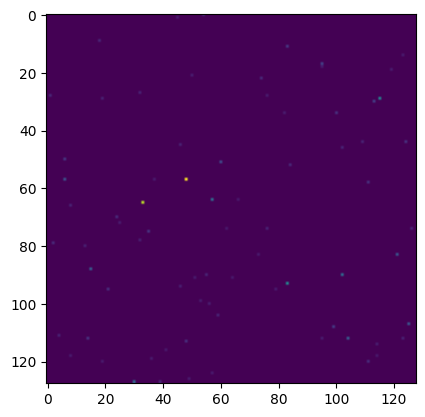

In [66]:
layer=20
m=cache[f'blocks.{layer}.hook_mlp_out.hook_sae_acts_post']
plt.imshow(m[0, -1, :].detach().cpu().numpy().reshape(128,128))

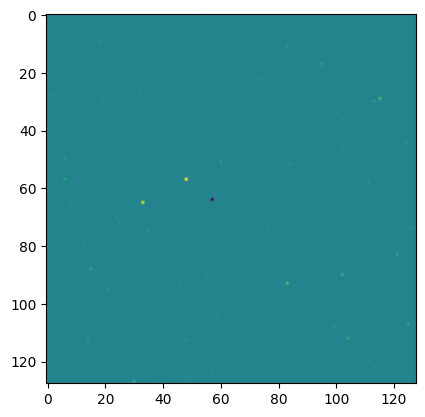

In [67]:
z=captured_sae_acts_post[layer]
plt.imshow(z[0, -1, :].detach().cpu().numpy().reshape(128,128))

In [70]:
(z[0, -1, :]-m[0, -1, :]).abs().max()

tensor(50., device='cuda:0')

In [55]:
residual_after_steering[20].shape

torch.Size([1, 7, 2304])

# Getting the features from each layer and comparing how much each feature effects the output

In [56]:
# Get the feature by feeding in the input from "captured"
z=captured_sae_acts_post[20].cpu().numpy()
top_indices = np.argsort(np.abs(z[0,-1]))[-10:][::-1]
print(top_indices)
print(z[0,-1][top_indices])

contribution = 14.649522 * gemma_2_2b_all_sae[20].W_dec[8249].detach().cpu().numpy()
contribution = np.power(contribution, 2).sum()
recon = captured_sae_recons[20].cpu().numpy()
recon = np.power(recon, 2).sum()
frac = contribution/recon
frac

[ 7344  8353 11987  3827 11622 16286 11279 14440 10745 13821]
[43.1297    38.718006  19.613232  18.810635  14.325588  13.920195
 12.1156025 12.091032  10.924782  10.898737 ]


0.0033685113

In [128]:
from sklearn.decomposition import PCA

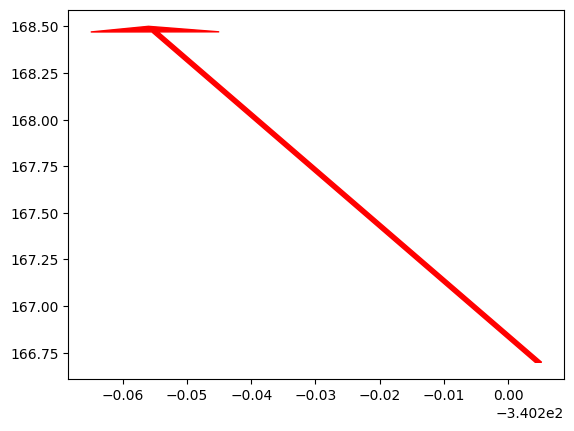

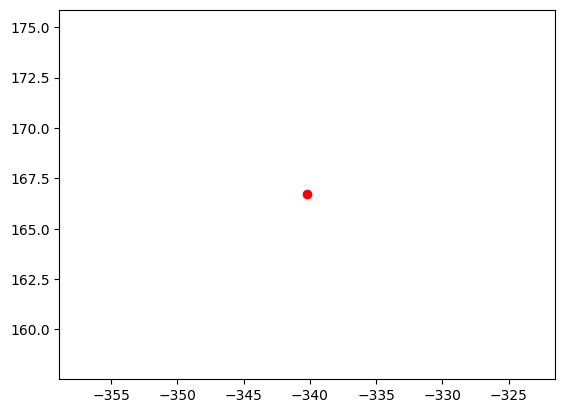

In [141]:
act = residual_after_steering[20][0].detach().cpu().numpy()
pca = PCA(n_components=2, random_state=42)
act_pca = pca.fit_transform(act)  

feature_direction = 14.649522 * gemma_2_2b_all_sae[20].W_dec[8249].detach().cpu().numpy()
feature_2d = feature_direction @ pca.components_.T

# Base point for the arrow (e.g., last token)
x0, y0 = act_pca[-1]

# Arrow vector
dx, dy = feature_2d

# Draw arrow
plt.arrow(
    x0, y0,      # starting point
    dx, dy,      # delta x and y
    head_width=0.02,  # size of arrow head
    head_length=0.03, 
    fc='red', ec='red',  # arrow color
    length_includes_head=True
)

plt.figure()
plt.scatter(act_pca[-1,0], act_pca[-1,1], color="r")
plt.show()

# ---------------------------------------

In [160]:
gemma_2_2b.reset_hooks()
latent_idx=12568    
sae_layer=14
_no_steering_hook = partial(
    steering_hook,
    sae=gemma_2_2b_all_sae[sae_layer],
    latent_idx=latent_idx,
    layer_idx=sae_layer,
    steering_coefficient=0,
)

residual_no_steering = {}

def capture_residual_hook_no_steering(layer_idx):
    def hook_fn(
        activation: Float[Tensor, "batch pos d_model"],
        hook: HookPoint,
    ) -> None:
        """Capture residual stream for specific layer."""
        residual_no_steering[layer_idx] = activation.clone()
    return hook_fn
# Add hooks to capture residuals
residual_hooks_no_steering = []
for layer in range(26):
    residual_hooks_no_steering.append((f"blocks.{layer}.hook_resid_post", capture_residual_hook_no_steering(layer)))

# with gemma_2_2b.hooks(fwd_hooks=[("blocks.20.hook_mlp_out", _no_steering_hook), *residual_hooks_no_steering]):
#     _, cache = gemma_2_2b.run_with_cache_with_saes(
#         prompt,
#         saes=gemma_2_2b_all_sae,
#         stop_at_layer=25+1,
#     )

In [161]:
with gemma_2_2b.hooks(fwd_hooks=[(f"blocks.{sae_layer}.hook_mlp_out", _no_steering_hook), *residual_hooks_no_steering]):
    utils.test_prompt(prompt, "safer", gemma_2_2b)
    l, c = gemma_2_2b.run_with_cache_with_saes(
        prompt,
        saes=gemma_2_2b_all_sae
    )

# Get probabilities
probs = torch.softmax(l[0, -1, :], dim=-1)
top_probs, top_indices = torch.topk(probs, k=10)

for i in range(10):
    token = gemma_2_2b.to_string(top_indices[i])
    print(f"{token}: {top_probs[i].item():.2%}")

Tokenized prompt: ['<bos>', 'The', ' safety', ' of', ' nuclear', ' energy', ' is', ' often']
Tokenized answer: [' safer']


Performance on answer token:
Rank: 560      Logit: 15.86 Prob:  0.00% Token: | safer|

Top 0th token. Logit: 25.97 Prob: 16.83% Token: | questioned|
Top 1th token. Logit: 25.34 Prob:  8.98% Token: | debated|
Top 2th token. Logit: 25.16 Prob:  7.54% Token: | a|
Top 3th token. Logit: 25.07 Prob:  6.87% Token: | discussed|
Top 4th token. Logit: 25.06 Prob:  6.78% Token: | cited|
Top 5th token. Logit: 24.46 Prob:  3.74% Token: | the|
Top 6th token. Logit: 24.40 Prob:  3.50% Token: | called|
Top 7th token. Logit: 24.18 Prob:  2.81% Token: | compared|
Top 8th token. Logit: 24.14 Prob:  2.71% Token: | touted|
Top 9th token. Logit: 24.02 Prob:  2.40% Token: | criticized|


Ranks of the answer tokens: [(' safer', 560)]

runnin'
runnin'
runnin'
runnin'
runnin'
 a: 14.57%
 the: 11.60%
 considered: 6.81%
 an: 5.11%
 discussed: 3.89%
 one: 3.01%
 associated: 2.27%
 regarded: 2.08%
 taken: 1.98%
 seen: 1.95%


In [43]:
from sklearn.decomposition import PCA

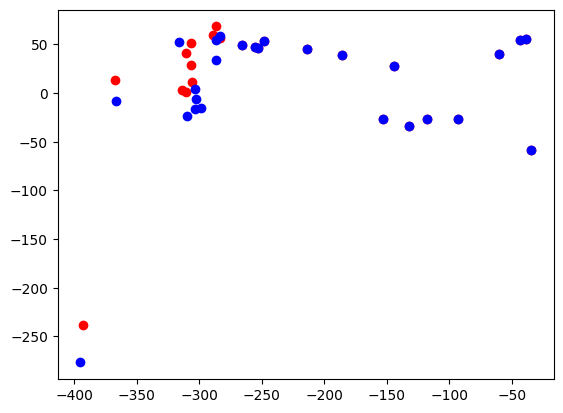

In [44]:
x_after_steering = []
y_after_steering = []
x_before = []
y_before = []
for layer, act in residual_after_steering.items():
    act_pca = PCA(n_components=2, random_state=42).fit_transform(act[0].detach().cpu().numpy())
    x_after_steering.append(act_pca[-1,0])
    y_after_steering.append(act_pca[-1,1])

for layer, act in residual_no_steering.items():
    act_pca = PCA(n_components=2, random_state=42).fit_transform(act[0].detach().cpu().numpy())
    x_before.append(act_pca[-1,0])
    y_before.append(act_pca[-1,1])

plt.figure()
plt.scatter(x_after_steering, y_after_steering, color="r")
plt.scatter(x_before, y_before, color="b")
plt.show()

In [45]:
# 1. take the NEXT-TOKEN position
r_next = residual_no_steering[25][:, -2, :]                      # [batch, d_model]

# 2. apply final layernorm
r_next = gemma_2_2b.ln_final(r_next)

# 3. unembed to vocab
logits = gemma_2_2b.unembed(r_next)       # [batch, vocab]

# 4. convert to probabilities
probs = logits.softmax(dim=-1)

# 5. inspect top tokens
top_probs, top_ids = probs[0].topk(10)
for tk, p in zip(top_ids, top_probs):
    print(gemma_2_2b.to_string(tk.item()), float(p))


 questioned 0.8022507429122925
 debated 0.07725120335817337
 a 0.04227868467569351
 discussed 0.031001562252640724
 cited 0.029763570055365562
 the 0.004574570804834366
 called 0.0037558695767074823
 compared 0.0020006559789180756
 touted 0.0018048032652586699
 criticized 0.0012702494859695435


# Checking SAE features from steered and unsteered model

In [179]:
logits_no_steering, cache_no_steering = gemma_2_2b.run_with_cache_with_saes(prompt, saes=gemma_2_2b_all_sae)

for name, param in cache.items():
    if "hook_sae" in name:
        print(f"{name:<43}: {tuple(param.shape)}")

utils.test_prompt(prompt, "safer", gemma_2_2b)

blocks.0.hook_mlp_out.hook_sae_input       : (1, 8, 2304)
blocks.0.hook_mlp_out.hook_sae_acts_pre    : (1, 8, 16384)
blocks.0.hook_mlp_out.hook_sae_acts_post   : (1, 8, 16384)
blocks.0.hook_mlp_out.hook_sae_recons      : (1, 8, 2304)
blocks.0.hook_mlp_out.hook_sae_output      : (1, 8, 2304)
blocks.1.hook_mlp_out.hook_sae_input       : (1, 8, 2304)
blocks.1.hook_mlp_out.hook_sae_acts_pre    : (1, 8, 16384)
blocks.1.hook_mlp_out.hook_sae_acts_post   : (1, 8, 16384)
blocks.1.hook_mlp_out.hook_sae_recons      : (1, 8, 2304)
blocks.1.hook_mlp_out.hook_sae_output      : (1, 8, 2304)
blocks.2.hook_mlp_out.hook_sae_input       : (1, 8, 2304)
blocks.2.hook_mlp_out.hook_sae_acts_pre    : (1, 8, 16384)
blocks.2.hook_mlp_out.hook_sae_acts_post   : (1, 8, 16384)
blocks.2.hook_mlp_out.hook_sae_recons      : (1, 8, 2304)
blocks.2.hook_mlp_out.hook_sae_output      : (1, 8, 2304)
blocks.3.hook_mlp_out.hook_sae_input       : (1, 8, 2304)
blocks.3.hook_mlp_out.hook_sae_acts_pre    : (1, 8, 16384)
blocks.

Performance on answer token:
Rank: 560      Logit: 15.86 Prob:  0.00% Token: | safer|

Top 0th token. Logit: 25.97 Prob: 16.83% Token: | questioned|
Top 1th token. Logit: 25.34 Prob:  8.98% Token: | debated|
Top 2th token. Logit: 25.16 Prob:  7.54% Token: | a|
Top 3th token. Logit: 25.07 Prob:  6.87% Token: | discussed|
Top 4th token. Logit: 25.06 Prob:  6.78% Token: | cited|
Top 5th token. Logit: 24.46 Prob:  3.74% Token: | the|
Top 6th token. Logit: 24.40 Prob:  3.50% Token: | called|
Top 7th token. Logit: 24.18 Prob:  2.81% Token: | compared|
Top 8th token. Logit: 24.14 Prob:  2.71% Token: | touted|
Top 9th token. Logit: 24.02 Prob:  2.40% Token: | criticized|


Ranks of the answer tokens: [(' safer', 560)]

In [188]:
# Use the same steering hook above where there is a noticable change in output token distribution
gemma_2_2b.reset_hooks()
latent_idx=12568
sae_layer=14
_steering_hook = partial(
    steering_hook,
    sae=gemma_2_2b_all_sae[sae_layer],
    latent_idx=latent_idx,
    steering_coefficient=100,
)

# features_after_steering = []
residual_after_steering = {}

def capture_residual_hook(layer_idx):
    def hook_fn(
        activation: Float[Tensor, "batch pos d_model"],
        hook: HookPoint,
    ) -> None:
        """Capture residual stream for specific layer."""
        residual_after_steering[layer_idx] = activation.clone()
    return hook_fn
# Add hooks to capture residuals
residual_hooks_after_steering = []
for layer in range(26):
    residual_hooks_after_steering.append((f"blocks.{layer}.hook_resid_post", capture_residual_hook(layer)))

with gemma_2_2b.hooks(fwd_hooks=[(f"blocks.{sae_layer}.hook_mlp_out", _steering_hook), *residual_hooks_after_steering]):
    utils.test_prompt(prompt, "safer", gemma_2_2b)
    # logits_after_steering, cache_after_steering = gemma_2_2b.run_with_cache_with_saes(prompt, saes=gemma_2_2b_all_sae)

    for name, param in cache.items():
        if "hook_sae" in name:
            print(f"{name:<43}: {tuple(param.shape)}")


Tokenized prompt: ['<bos>', 'The', ' safety', ' of', ' nuclear', ' energy', ' is', ' often']
Tokenized answer: [' safer']


Performance on answer token:
Rank: 660      Logit: 16.44 Prob:  0.00% Token: | safer|

Top 0th token. Logit: 25.73 Prob:  7.49% Token: | questioned|
Top 1th token. Logit: 25.33 Prob:  5.06% Token: | a|
Top 2th token. Logit: 25.17 Prob:  4.30% Token: | cited|
Top 3th token. Logit: 25.13 Prob:  4.12% Token: | touted|
Top 4th token. Logit: 25.00 Prob:  3.61% Token: | used|
Top 5th token. Logit: 24.94 Prob:  3.41% Token: | portrayed|
Top 6th token. Logit: 24.93 Prob:  3.39% Token: | overlooked|
Top 7th token. Logit: 24.78 Prob:  2.91% Token: | misunderstood|
Top 8th token. Logit: 24.65 Prob:  2.56% Token: | the|
Top 9th token. Logit: 24.65 Prob:  2.54% Token: | criticized|


Ranks of the answer tokens: [(' safer', 660)]

blocks.0.hook_mlp_out.hook_sae_input       : (1, 8, 2304)
blocks.0.hook_mlp_out.hook_sae_acts_pre    : (1, 8, 16384)
blocks.0.hook_mlp_out.hook_sae_acts_post   : (1, 8, 16384)
blocks.0.hook_mlp_out.hook_sae_recons      : (1, 8, 2304)
blocks.0.hook_mlp_out.hook_sae_output      : (1, 8, 2304)
blocks.1.hook_mlp_out.hook_sae_input       : (1, 8, 2304)
blocks.1.hook_mlp_out.hook_sae_acts_pre    : (1, 8, 16384)
blocks.1.hook_mlp_out.hook_sae_acts_post   : (1, 8, 16384)
blocks.1.hook_mlp_out.hook_sae_recons      : (1, 8, 2304)
blocks.1.hook_mlp_out.hook_sae_output      : (1, 8, 2304)
blocks.2.hook_mlp_out.hook_sae_input       : (1, 8, 2304)
blocks.2.hook_mlp_out.hook_sae_acts_pre    : (1, 8, 16384)
blocks.2.hook_mlp_out.hook_sae_acts_post   : (1, 8, 16384)
blocks.2.hook_mlp_out.hook_sae_recons      : (1, 8, 2304)
blocks.2.hook_mlp_out.hook_sae_output      : (1, 8, 2304)
blocks.3.hook_mlp_out.hook_sae_input       : (1, 8, 2304)
blocks.3.hook_mlp_out.hook_sae_acts_pre    : (1, 8, 16384)
blocks.

[[[-0.18927574  0.          0.         ...  0.          2.9454346
    0.        ]
  [ 0.          7.116108    0.         ...  1.932992    0.
    2.2009935 ]
  [-1.8450994   4.8821545   0.         ...  0.          0.
    6.187765  ]
  ...
  [ 0.          0.          0.         ...  0.          0.
    0.        ]
  [ 0.          0.          0.         ...  0.          0.
    0.        ]
  [ 0.20548248  0.          0.         ...  0.          0.
    0.        ]]]


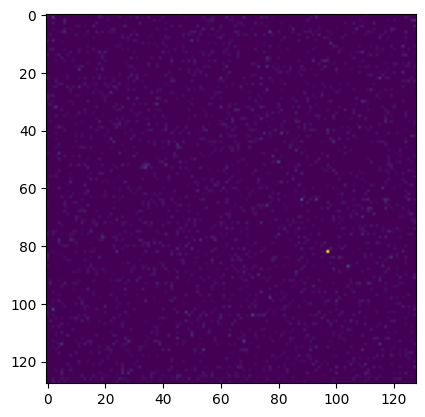

In [237]:
layer = 25
z_1 = gemma_2_2b_all_sae[layer].encode(residual_no_steering[layer][:,:-1,:]).detach().cpu().numpy()
z_2 = gemma_2_2b_all_sae[layer].encode(residual_after_steering[layer][:,:-1,:]).detach().cpu().numpy()
plt.imshow(z_2[0, -1, :].reshape(128,128))
print(z_2-z_1)

# Weight basis stuff

In [9]:
gemma_2_2b.blocks[0].attn.W_O

Parameter containing:
tensor([[[ 8.7549e-03,  1.0347e-02,  1.4814e-02,  ...,  2.7006e-03,
          -5.5830e-03,  8.9316e-03],
         [ 1.1620e-02,  2.0683e-02,  9.6936e-03,  ...,  9.3770e-04,
           1.0712e-02,  1.1793e-02],
         [ 5.5322e-03, -2.6992e-04,  1.3098e-03,  ...,  1.5343e-02,
           1.0903e-02,  4.8895e-03],
         ...,
         [ 2.1287e-03,  3.0223e-03, -6.1900e-03,  ...,  1.9287e-02,
          -4.0913e-03, -7.2594e-03],
         [-1.1614e-02,  5.3531e-03,  2.6939e-03,  ..., -7.7466e-03,
           3.6378e-03, -1.1533e-02],
         [-2.1368e-03,  2.1404e-02,  2.0708e-03,  ..., -1.2105e-02,
           7.3118e-03,  2.2581e-03]],

        [[ 1.2210e-02, -1.6283e-03, -2.2583e-02,  ..., -5.7778e-03,
          -9.7454e-03, -1.4998e-02],
         [ 5.4984e-03, -8.5513e-03, -8.8420e-04,  ...,  8.9662e-03,
          -1.0989e-02,  1.2817e-02],
         [ 2.2908e-03,  2.5557e-03,  6.3447e-03,  ...,  1.6730e-03,
          -6.5994e-03,  1.4023e-02],
         ...,
   

In [10]:
len(gemma_2_2b_all_sae[1].W_dec)

16384

In [11]:
def project_weights_to_next_attn(model, sae_w_dec, layer_idx):
    next_ln1 = model.blocks[layer_idx + 1].ln1
    return next_ln1(sae_w_dec)

layer_idx = 20
W_hat = project_weights_to_next_attn(gemma_2_2b, gemma_2_2b_all_sae[layer_idx].W_dec, layer_idx)

# W_Q = gemma_2_2b.blocks[layer_idx+1].attn.W_Q
# W_K = gemma_2_2b.blocks[layer_idx+1].attn.W_K
W_V = gemma_2_2b.blocks[layer_idx+1].attn.W_V
W_O = gemma_2_2b.blocks[layer_idx + 1].attn.W_O

# q_i = torch.einsum("fd,hdk->fhk", W_hat, W_Q)
# k_i = torch.einsum("fd,hdk->fhk", W_hat, W_K)
v_i = torch.einsum("fd,hdk->fhk", W_hat, W_V)
v_i_potential_per_head = torch.einsum("fhk,hkd->fhd", v_i, W_O)
v_i_potential_per_head_norm = torch.norm(v_i_potential_per_head, dim=-1)

# d_head = q_i.shape[-1]
# s_i = torch.einsum('ihd,jhd->ijh', q_i, k_i) / d_head**0.5
# a_i = F.softmax(s_i, dim=1)

# score = a_i.sum(dim=0).sum(dim=-1)

In [12]:
v_i_potential_per_head_norm.shape # For each feature per head

torch.Size([16384, 8])

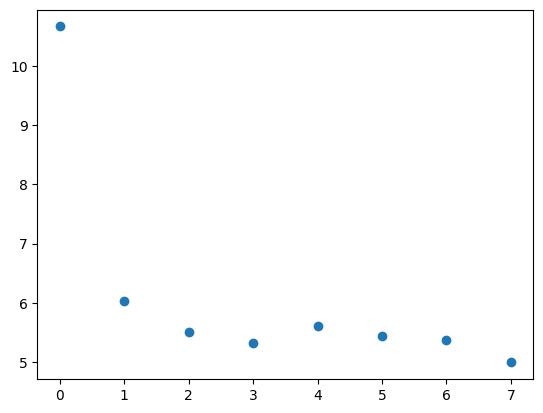

In [13]:
feature = 15000
plt.scatter(x=[i for i in range(len(v_i_potential_per_head_norm[feature, :]))], y=v_i_potential_per_head_norm[feature, :].detach().cpu().numpy())

In [14]:
v_i_potential_per_head_norm_total = v_i_potential_per_head_norm.sum(dim=-1)
v_i_potential_per_head_norm_total.shape

torch.Size([16384])

Text(0, 0.5, 'Write potential')

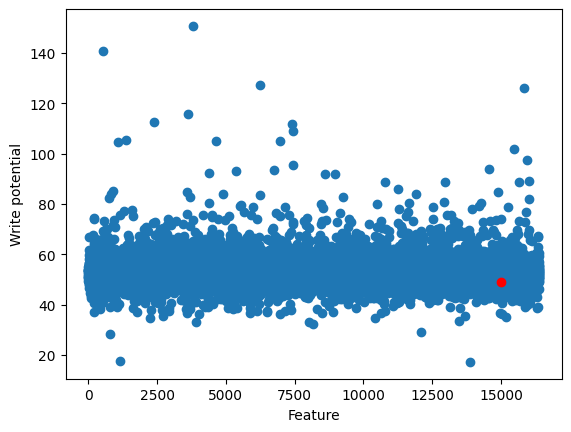

In [15]:
x = [i for i in range(len(v_i_potential_per_head_norm_total))]
y = v_i_potential_per_head_norm_total.detach().cpu().numpy()
plt.scatter(x=x, y=y)
plt.scatter(x=x[feature], y=y[feature], color='red')
plt.xlabel("Feature")
plt.ylabel("Write potential")

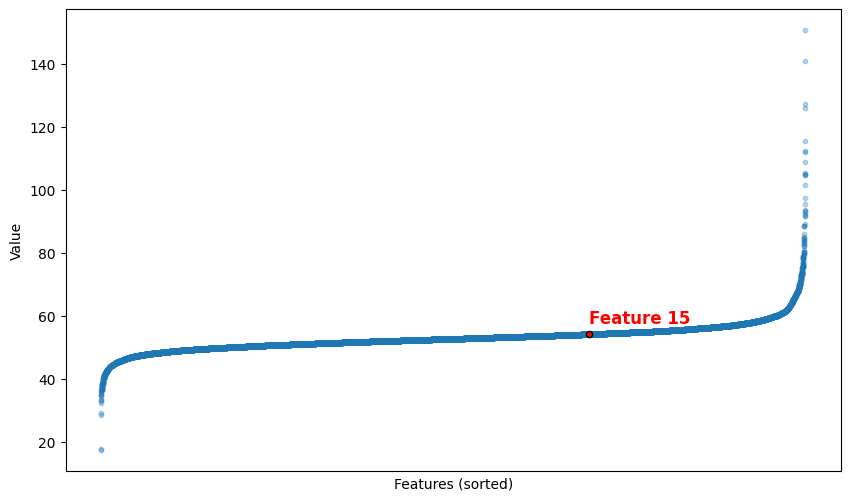

In [36]:
y_sorted = np.sort(y)
sorted_indices = np.argsort(y)

target_feature = 15
feature_pos_in_sorted = np.where(sorted_indices == target_feature)[0][0]
target_val = y_sorted[feature_pos_in_sorted]

plt.figure(figsize=(10, 6))

# 2. Plot background points
plt.scatter(range(len(y_sorted)), y_sorted, c='tab:blue', s=10, alpha=0.3)

# 3. Plot highlighted point
plt.scatter(feature_pos_in_sorted, target_val, c='red', s=20, edgecolors='black', zorder=5)

# 4. WRITE ON THE GRAPH (Annotation)
plt.annotate(
    f'Feature {target_feature}', 
    xy=(feature_pos_in_sorted, target_val),      # The point to label
    xytext=(feature_pos_in_sorted, target_val + 5), # Where to put the text (offset slightly to the right)
    fontsize=12,
    fontweight='bold',
    color='red',
    va='center'                                  # Vertical alignment
)

# 5. Clean up axis
plt.xticks([])
plt.xlabel("Features (sorted)")
plt.ylabel("Value")
plt.show()

In [9]:
import requests

def get_neuronpedia_info(model_id, sae_id, feature_idx):
    url = f"https://www.neuronpedia.org/api/feature/{model_id}/{sae_id}/{feature_idx}"
    try:
        response = requests.get(url, timeout=5)
        if response.status_code == 200:
            data = response.json()
            # Explanations are usually in a list; the first one is often the primary auto-interp
            explanations = data.get("explanations", [])
            return explanations[0]['description'].strip()
    except:
        return 'Unable to retrieve feature'

# Inside your loop/expander:
model = "gemma-2-2b" # or your specific model
sae = "20-gemmascope-mlp-16k" # your SAE set

get_neuronpedia_info(model, sae, 8249)

'phrases indicating questioning or debate about competency and accuracy in scientific or statistical contexts'